# **Clasificación de textos con PLN**

En este proyecto se aplican técnicas de Procesamiento del Lenguaje Natural (PLN) para analizar y clasificar textos utilizando modelos estadísticos y de aprendizaje automático. Se realizan etapas de preprocesamiento, vectorización y entrenamiento de modelos para evaluar su capacidad de clasificación y comparar resultados.

Se desarrollan dos proyectos representativos del Procesamiento del Lenguaje Natural:

1. El primero se centra en el **análisis de sentimientos**, comparando un enfoque clásico basado en la extracción de características (TF-IDF + Naive Bayes) frente a un modelo preentrenado basado en **Transformers (BERT)**, con el objetivo de comparar su desempeño en un contexto real.

2. El segundo proyecto aborda el procesamiento y la estructuración de textos clínicos, aplicando técnicas de limpieza, tokenización y reconocimiento de entidades nombradas (NER) para analizar patrones, visualizar la información y transformar texto no estructurado en datos analizables.

**Objetivo:** aplicar técnicas de PLN para clasificar textos automáticamente, comparar distintos enfoques y estructurar información textual mediante extracción de entidades

**Tecnologías usadas:**
- Python
- Scikit-learn
- NLTK / spaCy
- TF-IDF / Bag of Words
- Transformers (BERT)
- spaCy (NER)

**Resultados:**

**Proyecto 1: Análisis de sentimientos**

**Modelo 1: Enfoque clásico (TF-IDF + Naive Bayes)**

- Accuracy: 0.84
- F1 (macro): 0.84
- ROC-AUC: 0.92

El modelo clásico ofrece un rendimiento sólido y equilibrado entre clases, con métricas similares en precisión y recall para reseñas positivas y negativas. Destaca por su simplicidad, eficiencia computacional y buena capacidad de generalización.

**Modelo 2: Transformers (BERT)**

- Accuracy: 0.82
- F1 (macro): 0.82
- ROC-AUC: 0.93

El modelo basado en Transformers muestra una mayor capacidad de separación probabilística (ROC-AUC superior), aunque con una ligera reducción en accuracy respecto al enfoque clásico. Se observa mayor recall en la clase negativa y mayor precisión en la clase positiva.

**Comparación entre modelos:**
- El modelo clásico (TF-IDF + NB) obtiene mejor accuracy global.
- BERT presenta mejor ROC-AUC, indicando mayor capacidad de discriminación probabilística.
- El enfoque clásico demuestra que modelos simples pueden ser altamente competitivos en tareas de clasificación de texto.

**Proyecto 2: Procesamiento de textos clínicos (NER)**

Se aplicó reconocimiento de entidades nombradas (NER) con spaCy para extraer información estructurada a partir de texto clínico no estructurado.

**Resultados:**
- Identificación automática de entidades relevantes.
- Transformación del texto libre en datos estructurados.
- Análisis y visualización de patrones frecuentes.

Este enfoque demuestra la capacidad de convertir texto clínico en información analizable, facilitando su integración en futuros modelos predicitivos o sistemas de apoyo a la decisión.

En este notebook se abordan dos tareas de PLN:

1) **Clasificación de sentimientos (IMDB):** comparación de un enfoque clásico (TF-IDF + Naive Bayes) frente a un modelo basado en Transformers (BERT) usando un pipeline preentrenado.  
2) **Análisis de texto clínico:** limpieza y estructuración del texto y **extracción de entidades (NER)** con spaCy para obtener información cuantificable a partir de texto no estructurado.

Al final se reportan métricas (Accuracy, F1, ROC-AUC) y se analizan resultados y errores.

# **Proyecto 1: Análisis de sentimientos en datos textuales con modelos avanzados**

**Objetivo general:** desarrollar y evaluar distintos enfoques de análisis de sentimientos, comparando un modelo clásico basado en extracción de características con un modelo preentrenado como BERT basado en Transformers, para comparar su desempeño en contextos reales.

## Instalación de librerias de PLN y ML

Primero se preparan los recursos necesarios para ejecutar el notebook, instalando e importando las librerías utilizadas en el proyecto (como NLTK, scikit-learn, spaCy y Transformers) y descargando los paquetes lingüísticos requeridos. Estas etapas permiten configurar correctamente el entorno de trabajo y asegurar que las herramientas de preprocesamiento, modelado y evaluación de PLN estén disponibles antes de comenzar el análisis y entrenamiento de los modelos.

In [ ]:
# =========================================================
# PROYECTO 1 - Análisis de sentimientos
# =========================================================

# Instalación de librerias de PLN y ML (opcional)
!pip install -q nltk spacy scikit-learn transformers requests

# Descarga el modelo de spaCy
import spacy
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    from spacy.cli import download
    download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

In [ ]:
# Imports y configuración

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (classification_report, accuracy_score, f1_score, roc_auc_score)

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from transformers import pipeline

# Descargar recursos de NLTK (punkt_tab, stopwords)
nltk.download("punkt_tab")
nltk.download("stopwords")

# Definir stopwords
stop_words = set(stopwords.words("english"))

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## Carga y exploración de datos

En primer lugar, se carga un conjunto de datos compuesto por diferentes reseñas textuales etiquetadas según su polaridad, es decir, si son reseñas positivas o negativas. A continuación, se realiza una exploración inicial del dataset para comprobar su estructura, tamaño y distribución de clases. Esta exploración permite verificar que el conjunto de datos está equilibrado de modo que se pueda realizar una evaluación justa del rendimiento de los modelos.

In [ ]:
from urllib import request
# Carga del dataset

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

# URL del dataset (IMDb)
IMDB_URL = (
    "https://raw.githubusercontent.com/"
    "FarhanaTeli/Sentiment_Analysis_IMDB/main/IMDB%20Dataset.csv"
)
IMDB_PATH = DATA_DIR / "IMDB_Dataset.csv"

import requests

if not IMDB_PATH.exists():
    print("Descargando dataset...")
    # TODO: hacer petición HTTP y guardar en disco
    r = requests.get(IMDB_URL)
    r.raise_for_status()
    IMDB_PATH.write_bytes(r.content)
else:
    print("El archivo ya existe:", IMDB_PATH)

# Cargar el CSV en un DataFrame
df = pd.read_csv(IMDB_PATH)
print(df.head())
print(df["sentiment"].value_counts())


Descargando dataset...
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


El dataset IMDB se ha descargado correctamente y contiene reseñas de películas junto con su etiqueta de sentimiento (`positive` o `negative`). Al inspeccionar las primeras filas se confirma que los textos se han cargado correctamente en el DataFrame.

La distribución de la variable objetivo muestra 25 000 reseñas positivas y 25 000 negativas, lo que indica que el dataset está perfectamente equilibrado entre ambas clases. Esto es positivo para el entrenamiento de modelos de clasificación, ya que evita sesgos hacia una clase dominante y permite evaluar el rendimiento de forma más fiable.

## Limpieza y preprocesamiento

Para reducir el ruido y homogeneizar los textos se realiza una limpieza básica del texto mediante la definición de la función `clean_text`.

Esta función realiza los siguientes pasos:
- Conversión del texto a minúsculas
- Tokenización del texto mediante `word_tokenize()`
- Eliminación de tokens no alfabéticos usando `isalpha()`
- Eliminación de stopwords con `stopwords.words("english")`

Estas operaciones permiten reducir ruido y variabilidad en el lenguaje, facilitando que el modelo se centre en las palabras más informativas.

Posteriormente, la función se aplica a todas las reseñas para crear una nueva columna (`clean_text`) y se eliminan registros con textos vacíos o valores nulos, asegurando la calidad de los datos antes de la vectorización.

El resultado es un texto más homogéneo y con menos ruido, haciéndolo más adecuado para los modelos basados en extracción de características como TF-IDF.

In [ ]:
# Limpieza + preprocesamiento

# Definición de una función de limpieza básica:

def clean_text(text: str) -> str:
  if pd.isna(text):
    return ""

  #  Convertir a minúsculas
  text = str(text).lower()

  #  Tokenizar con word_tokenize
  tokens = word_tokenize(text)

  # Mantener solo los tokens alfabéticos
  tokens = [token for token in tokens if token.isalpha()]

  # Eliminar stopwords
  tokens = [token for token in tokens if token not in stop_words]

  return " ".join(tokens)

# Aplicar la función al texto original (por ejemplo df["review"])
df["clean_text"] = df["review"].apply(clean_text)
print(df["clean_text"])

# Eliminar textos vacíos tras la limpieza
df = df.dropna(subset=["clean_text", "sentiment"])

# Comprobar resultado
df[["review", "clean_text", "sentiment"]].head()


0        one reviewers mentioned watching oz episode ho...
1        wonderful little production br br filming tech...
2        thought wonderful way spend time hot summer we...
3        basically family little boy jake thinks zombie...
4        petter mattei love time money visually stunnin...
                               ...                        
49995    thought movie right good job creative original...
49996    bad plot bad dialogue bad acting idiotic direc...
49997    catholic taught parochial elementary schools n...
49998    going disagree previous comment side maltin on...
49999    one expects star trek movies high art fans exp...
Name: clean_text, Length: 50000, dtype: object


,review,clean_text,sentiment
0,One of the other reviewers has mentioned that ...,one reviewers mentioned watching oz episode ho...,positive
1,A wonderful little production. <br /><br />The...,wonderful little production br br filming tech...,positive
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...,positive
3,Basically there's a family where a little boy ...,basically family little boy jake thinks zombie...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visually stunnin...,positive


El proceso de limpieza se ha aplicado correctamente a las 50 000 reseñas, generando una nueva columna (`clean_text`) con los textos normalizados. Se observa que los textos resultantes están en minúsculas, sin signos de puntuación ni stopwords, y contienen únicamente palabras relevantes, lo que facilita su posterior vectorización y entrenamiento de modelos.

Al comparar las columnas `review` y `clean_text`, se confirma que el contenido original se mantiene, pero con una representación más compacta y homogénea. Este preprocesamiento reduce el ruido del lenguaje natural y ayuda a mejorar el rendimiento de los modelos de clasificación.

**Definición de las variables de entrada y salida**

- **Variable de entrada `X`:** corresponde a los textos preprocesados (`clean_text`).
- **Variable objetivo `y`:** indica el sentimiento asociado a cada reseña (positive o negative).

**División del conjunto de datos**

El dataset se divide en conjuntos de entrenamiento y prueba, utilizando un 80% de los datos para entrenar el modelo y el 20% restante para evaluar su rendimiento con textos no vistos.

Se emplea el parámetro `stratify = y` para mantener la misma proporción de clases en ambos conjuntos, lo que permite una evaluación más fiable y evita posibles sesgos en el modelo.

In [ ]:
# Definir variables de entrada 'X' y la salida 'y'
X = df["clean_text"]
y = df["sentiment"]

# Dividir en train y test manteniendo la proporción de clases
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = RANDOM_STATE, stratify = y)

len(X_train), len(X_test)


(40000, 10000)

## **Construcción del modelo TF-IDF + Naive Bayes**

Se construye un modelo clásico de clasificación de texto utilizando un enfoque de bag of words.

Primero, las reseñas se transforman a una representación numérica mediante TF-IDF, que asigna mayor peso a las palabras más informativas y reduce el impacto de términos muy frecuentes. Se limitan las características a las 1000 más relevantes (`max_features=1000`) e incluyen unigramas y bigramas (`ngram_range=(1,2)`) para capturar expresiones cortas asociadas al sentimiento. Además, se aplican filtros de frecuencia (`min_df`, `max_df`) para reducir ruido.

Una vez vectorizado el texto, se entrena un clasificador Multinomial Naive Bayes, un baseline habitual y eficiente en NLP.

Finalmente, se evalúa el rendimiento en el conjunto de prueba mediante Accuracy, F1 (macro) y ROC-AUC, además del classification report para analizar precisión y recall por clase.

In [ ]:
# Modelo TF-IDF + Naive Bayes

# Vectorización TF-IDF del texto
tfidf = TfidfVectorizer(
    max_features=1000,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.7,
    sublinear_tf=True
)

# Ajuste y transformación del vectorizador con los datos de entrenamiento
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Entrenamos el clasificador Naive Bayes
nb_clf = MultinomialNB()
nb_clf.fit(X_train_tfidf, y_train)

# Predecimos y calculamos métricas
y_pred_nb = nb_clf.predict(X_test_tfidf)

# Probabilidad de la clase positiva (para ROC-AUC)
y_proba_nb = nb_clf.predict_proba(X_test_tfidf)[:, 1]
y_test_bin = (y_test == "positive").astype(int)

# Métricas
acc_nb = accuracy_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb, average="macro")
roc_nb = roc_auc_score(y_test_bin, y_proba_nb)

print("=== Modelo 1: TF-IDF + Naive Bayes ===")
print("Accuracy:", acc_nb)
print("F1 (macro):", f1_nb)
print("ROC-AUC:", roc_nb)
print()
print(classification_report(y_test, y_pred_nb))

=== Modelo 1: TF-IDF + Naive Bayes ===
Accuracy: 0.8399
F1 (macro): 0.8398390988173253
ROC-AUC: 0.91676304

              precision    recall  f1-score   support

    negative       0.85      0.82      0.84      5000
    positive       0.83      0.86      0.84      5000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



El modelo basado en TF-IDF + Naive Bayes obtiene una accuracy de 0.84, un F1-score de 0.84 y un ROC-AUC de 0.92, lo que indica un buen rendimiento general en la clasificación de sentimientos.

El F1-score es similar en ambas clases y muestra que el modelo mantiene un equilibrio entre reseñas positivas y negativas, sin favorecer claramente a ninguna de ellas. En concreto, el modelo presenta una precisión ligeramente mayor en la clase negativa (0.85) y un recall algo superior en la clase positiva (0.86), lo que sugiere un comportamiento equilibrado y estable.

El valor alto de ROC-AUC indica que el modelo tiene buena capacidad para distinguir entre sentimientos positivos y negativos, incluso cuando se utilizan probabilidades de predicción.

## **Construcción del modelo BERT (Transformers)**

En esta sección se utiliza un modelo basado en Transformers mediante el `pipeline("sentiment-analysis")`. A diferencia del enfoque clásico TF-IDF, BERT incorpora información de contexto y suele manejar mejor negaciones y dependencias largas del lenguaje.

Para reducir el coste computacional, se evalúa el modelo sobre una muestra aleatoria de 1000 reseñas del conjunto de test. Posteriormente, se convierten las etiquetas reales a formato binario para calcular ROC-AUC.

Dado que el pipeline devuelve una etiqueta y un score (confianza de la clase predicha), se define una función auxiliar que:

1. Transforma las etiquetas del pipeline a positive / negative
2. Obtiene una probabilidad aproximada de clase positiva (necesaria para ROC-AUC).

Finalmente, se evalúa el rendimiento del modelo con Accuracy, F1 (macro) y ROC-AUC, además del classification report para analizar precisión y recall por clase.

In [ ]:
# Modelo BERT (Transformers)

# Creamos el pipeline de análisis de sentimientos con BERT
hf_classifier = pipeline("sentiment-analysis")

# Seleccionamos una muestra del conjunto de test
N_SAMPLE = 1000
idx_sample = np.random.choice(len(X_test), size=N_SAMPLE, replace=False)
X_test_sample = X_test.iloc[idx_sample].to_list()
y_test_sample = y_test.iloc[idx_sample].to_list()

# Convertimos etiquetas a binario para POC-AUC
y_test_sample_bin = (pd.Series(y_test_sample) == "positive").astype(int).values

def hf_predict_with_scores(texts):
    """
    Aplica el pipeline de transformers y devuelve
      - etiquetas 'positive'/'negative'
      - score aproximado de la clase positiva
    """
    results = hf_classifier(texts, truncation = True)

    # Inicializamos las listas vacías
    labels = []
    pos_scores = []

    # Procesamiento de cada texto de forma individual
    for result in results:
      label = result["label"].lower()     # Extracción de la etiqueta devuelta por el modelo ("positive" o "negative")
      score = float(result["score"])      # Extracción de la confianza del modelo en la etiquieta predicha

      if "pos" in label:                  # Si la predicción es positiva
        labels.append("positive")
        pos_scores.append(score)          # Probabilidad positiva
      else:
        labels.append("negative")
        pos_scores.append(1 - score)      # Aproximación de probabilidad positiva

    return np.array(labels), np.array(pos_scores)

# Predicciones con BERT
y_pred_bert, y_score_bert = hf_predict_with_scores(X_test_sample)

# Metricas: calcular accuracy, F1 y ROC-AUC de BERT
acc_bert = accuracy_score(y_test_sample, y_pred_bert)
f1_bert = f1_score(y_test_sample, y_pred_bert, average="macro")
roc_bert = roc_auc_score(y_test_sample_bin, y_score_bert)

print("=== Modelo 2: BERT (pipeline) ===")
print("Accuracy:", acc_bert)
print("F1 (macro):", f1_bert)
print("ROC-AUC:", roc_bert)
print()
print(classification_report(y_test_sample, y_pred_bert))

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cpu


=== Modelo 2: BERT (pipeline) ===
Accuracy: 0.819
F1 (macro): 0.8179204503501258
ROC-AUC: 0.9332556957567464

              precision    recall  f1-score   support

    negative       0.76      0.92      0.83       489
    positive       0.90      0.73      0.80       511

    accuracy                           0.82      1000
   macro avg       0.83      0.82      0.82      1000
weighted avg       0.83      0.82      0.82      1000



TF-IDF + NB    | Accuracy: 0.8399 | F1: 0.8398 | ROC-AUC: 0.9168
BERT (pipeline)| Accuracy: 0.8190 | F1: 0.8179 | ROC-AUC: 0.9333


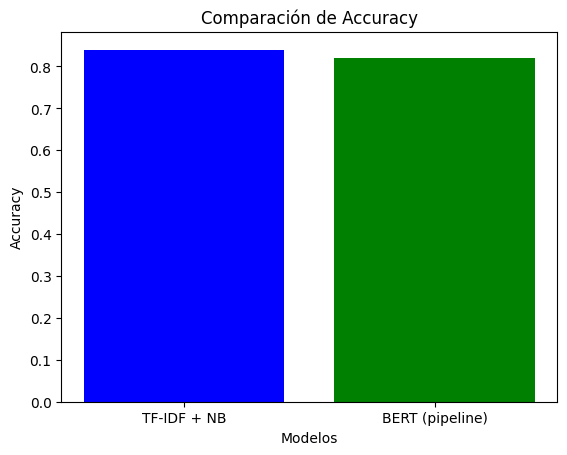

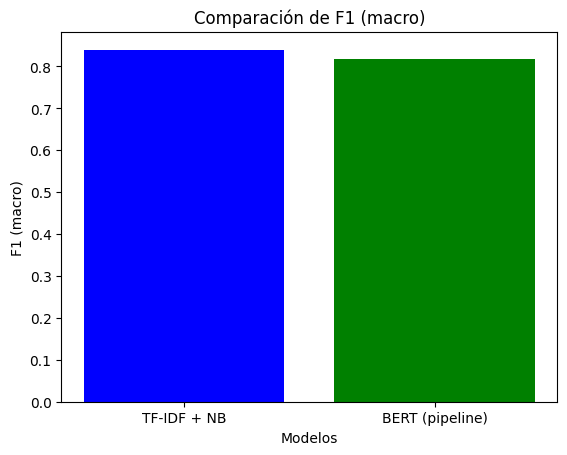

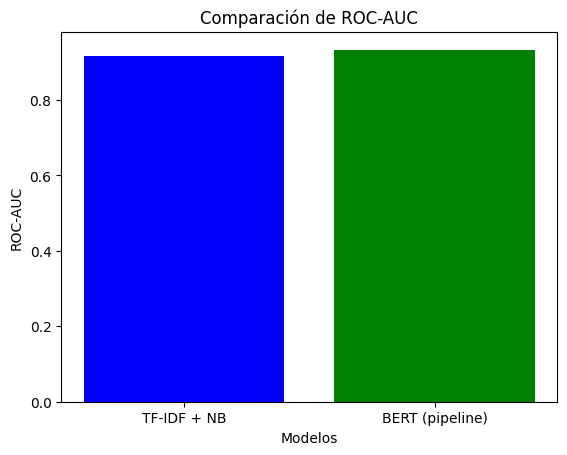

In [ ]:
# Comparación y gráfica

# Construir listas de métricas para ambos modelos
models = ["TF-IDF + NB", "BERT (pipeline)"]
accs = [acc_nb, acc_bert]
f1s = [f1_nb, f1_bert]
rocs = [roc_nb, roc_bert]

for m, a, f, r in zip(models, accs, f1s, rocs):
     print(f"{m:15s}| Accuracy: {a:.4f} | F1: {f:.4f} | ROC-AUC: {r:.4f}")


# Comparación de Accuracy
plt.figure()
plt.bar(models, accs, color=['blue', 'green'])
plt.title("Comparación de Accuracy")
plt.xlabel("Modelos")
plt.ylabel("Accuracy")
plt.show()

# Comparación de F1 (macro)
plt.figure()
plt.bar(models, f1s, color=['blue', 'green'])
plt.title("Comparación de F1 (macro)")
plt.xlabel("Modelos")
plt.ylabel("F1 (macro)")
plt.show()

# Comparación de ROC-AUC
plt.figure()
plt.bar(models, rocs, color=['blue', 'green'])
plt.title("Comparación de ROC-AUC")
plt.xlabel("Modelos")
plt.ylabel("ROC-AUC")
plt.show()

## Descripción de los modelos implementados

El **modelo clásico, basado en TF-IDF y Naive Bayes**, utiliza `TfidfVectorizer()` para la extracción de características y se entrena con un clasificador Multinomial de Naive Bayes. TF-IDF transforma los textos en vectores numéricos ponderando la importancia de los términos, mientras que Naive Bayes actúa como un clasificador probabilístico.


En cambio, **el modelo basado en Transformers**, utiliza un modelo BERT a través del `pipeline(“sentiment-analysis”)`. Este modelo ha sido previamente entrenado sobre grandes corpus y es capaz de capturar relaciones contextuales complejas entre palabras. Para poder evaluar este modelo con las mismas métricas y en las mismas condiciones que con el modelo anterior, se define una función llamada `hf_predict_with_scores` que aplica el pipeline de Transformers, adapta las etiquetas devueltas (positive y negative) y construye un score aproximado de la clase positiva.

## Resultados y comparación

Para la evaluación de los modelos se han calculado las métricas de Accuracy, F1-score y ROC-AUC, tal y como se indica en el enunciado de la actividad.

Los resultados obtenidos muestran que ambos modelos alcanzan valores similares de precisión y F1-score, aunque el modelo clásico basado en TF-IDF y Naive Bayes presenta valores ligeramente superiores, situándose alrededor de 0.84. Esto indica que el modelo Naive Bayes es capaz de capturar gran parte de la información relevante en el texto y clasificar las reseñas de forma equilibrada entre las dos clases.

En el caso del modelo preentrenado basado en BERT, los valores de Accuracy u F1-score se sitúan alrededor de 0.82. No obstante, al analizar el informe de clasificación por clase, se observa que la precisión para la clase positiva alcanza el 0.90, lo que implica que el modelo clasifica correctamente el 90% de las reseñas que predice como positivas. Por el contrario, la precisión para la clase negativa es del 76%, lo que indica que el modelo presenta más dificultades para clasificar correctamente las reseñas negativas.

A pesar de estas diferencias, el modelo preentrenado obtiene un valor ligeramente superior de ROC-AUC, lo que sugiere una mejor capacidad para separar ambas clases cuando se consideran las probabilidades de predicción. Esto refleja que, aunque el rendimiento global del modelo BERT es ligeramente inferior en métricas basadas en etiquetas, su modelado probabilístico resulta más eficaz para distinguir entre reseñas positivas y negativas.

## Conclusión

En este proyecto se observa que los modelos clásicos siguen siendo competitivos en tareas de análisis de sentimientos. El uso de modelos basados en BERT aporta algunas mejoras, especialmente en métricas basadas en scores como ROC-AUC, lo que refleja una mejor capacidad de separación entre clases. No obstante, en este caso en particular, personalmente optaría por el modelo clásico, por la sencillez, el rendimiento que ofrece y la baja complejidad requerida, aunque este es un problema relativamente sencillo.


# **Proyecto 2: Procesar y estructurar textos clínicos con modelos avanzados**

**Objetivo general:** utilizar herramientas de procesamiento de lenguaje natural de alto nivel para procesar y estructurar estos textos clínicos mediante técnicas de PLN, aplicando limpieza, tokenización y reconocimiento de entidades nombradas para extraer información relevante en un contexto clínico.

In [ ]:
# =========================================================
# PROYECTO 2 - Notas clínicas
# Dataset: Glaucoma_Med_Dataset
# =========================================================

# Instalación de librerias
!pip install -q nltk spacy scikit-learn requests

import spacy
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    from spacy.cli import download
    download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

In [ ]:
# Imports y configuración

import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Descargar recursos de NLTK (punkt_tab, stopwords)
nltk.download("punkt_tab")
nltk.download("stopwords")

# Definir stopwords
stop_words = set(stopwords.words("english"))

plt.rcParams["figure.figsize"] = (8, 4)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Carga y exploración de datos

Para realizar el segundo proyecto contamos con un conjunto de notas clínicas no identificadas obtenidas de un repositorio público. Estas notas se cargan en un DataFrame asignando un identificador único a cada una. En este paso también se realiza una exploración inicial para comprobar la longitud y variabilidad de los textos, así como características habituales de este tipo de textos.

In [ ]:

# Descarga del dataset Glaucoma_Med_Dataset

# Fuente: https://github.com/jche253/Glaucoma_Med_Dataset
# Contiene 481 notas clínicas desidentificadas de pacientes
# con glaucoma, más anotaciones de medicación. :contentReference[oaicite:1]{index=1}

import requests
import zipfile
import io

DATA_DIR = Path("data_clinical")
DATA_DIR.mkdir(exist_ok=True)

ZIP_PATH = DATA_DIR / "Glaucoma_Med_Dataset_main.zip"
EXTRACT_DIR = DATA_DIR / "Glaucoma_Med_Dataset"

REPO_ZIP_URL = "https://github.com/jche253/Glaucoma_Med_Dataset/archive/refs/heads/main.zip"

if not EXTRACT_DIR.exists():
    print("Descargando Glaucoma_Med_Dataset...")
    r = requests.get(REPO_ZIP_URL)
    r.raise_for_status()
    ZIP_PATH.write_bytes(r.content)

    print("Extrayendo zip...")
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(EXTRACT_DIR)
    print("Extracción completada.")
else:
    print("El dataset clínico ya está descargado.")

# Ruta esperada de las notas desidentificadas
base_repo_dir = next(EXTRACT_DIR.glob("Glaucoma_Med_Dataset-*"))
notes_dir = base_repo_dir / "Deidentified_Notes"

print("Directorio de notas:", notes_dir)
print("Número de archivos de nota:", len(list(notes_dir.iterdir())))

Descargando Glaucoma_Med_Dataset...
Extrayendo zip...
Extracción completada.
Directorio de notas: data_clinical/Glaucoma_Med_Dataset/Glaucoma_Med_Dataset-main/Deidentified_Notes
Número de archivos de nota: 480


In [ ]:

# Cargar notas clínicas en un DataFrame


texts = []
note_ids = []

for i, f in enumerate(sorted(notes_dir.iterdir()), start=1):
    if f.is_file():
        try:
            txt = f.read_text(encoding="utf-8")
        except UnicodeDecodeError:
            txt = f.read_text(encoding="latin-1", errors="ignore")
        texts.append(txt)
        note_ids.append(i)

clinical_df = pd.DataFrame({
    "note_id": note_ids,
    "text": texts
})

print("Total de notas cargadas:", len(clinical_df))
clinical_df.head()

Total de notas cargadas: 480


,note_id,text
0,1,***** *** ********* Progress Note */**/****...
1,2,Glaucoma Clinic Note: **/**/**** Glaucoma D...
2,3,***** *** ********* Progress Note */**/****...
3,4,***** *** ********* Progress Note */**/**** C...
4,5,***** *** ********* Progress Note */**/**** C...


## Limpieza y tokenización

Para el preprocesamiento de los textos se usa `clean_text_2`. Una función definida en el primer proyecto, pero aplicando un pequeño cambio, ya que conserva tokens alfanuméricos en lugar de únicamente los alfabéticos. Esto es debido a que en los textos clínicos es frecuente que haya números que puedan ser relevantes en la toma de decisiones del modelo. La función, al igual que en el primer proyecto también convierte los datos a minúsculas, tokeniza el contenido y elimina stopwords. Tras la limpieza también se eliminan aquellos textos que quedan vacíos.

In [ ]:

# Limpieza + Tokenización (NLTK)


def clean_text_2(text: str) -> str:
  if pd.isna(text):
    return ""

  #  Convertir a minúsculas
  text = str(text).lower()

  #  Tokenizar con word_tokenize
  tokens = word_tokenize(text)

  # Mantener solo los tokens alfanuméricos (letras y números)
  tokens = [token for token in tokens if token.isalnum()]

  # Eliminar stopwords
  tokens = [token for token in tokens if token not in stop_words]

  return " ".join(tokens)

# Aplicar la función al texto clinico
clinical_df["clean_text"] = clinical_df["text"].apply(clean_text_2)

# Eliminar textos vacíos tras la limpieza
clinical_df = clinical_df.dropna(subset=["clean_text"])

# Comprobar resultado
clinical_df[["note_id", "clean_text"]].head()


,note_id,clean_text
0,1,progress note cc annual health maintenance exa...
1,2,glaucoma clinic note glaucoma diagnosis referr...
2,3,progress note cc glaucoma hpi 82 female patien...
3,4,progress note cc iop check intraocular pressur...
4,5,progress note cc iop check intraocular pressur...


## Reconocimiento de Entidades Nombradas (NER)

Después de procesar los textos, se aplica spaCy para realizar el reconocimiento de entidades nombradas sobre el texto. Se usa `doc.ents` para identificar entidades relevantes como organizaciones, fechas, localizaciones o referencias numéricas. Seguidamente se define un DataFrame para ir almacenando las entidades junto con su tipo y su posición dentro del documento.

In [ ]:

# NEER con spaCy

def extract_ents (note_id, text):
  # Procesamos el texto con spaCy
  doc = nlp(text)
  rows = []

  # Recorremos las entidades detectadas
  for ent in doc.ents:
    rows.append([
       note_id,           # Identificador del informe
       ent.text,          # Texto de la entidad
       ent.label_,        # Tipo de entidad
       ent.start_char,    # Posición inicial
       ent.end_char])     # Posición final
  return rows

# Exrtraemos entidades de una muestra de informes clínicos
rows = []

for _, r in clinical_df.head(59).iterrows():
  rows.extend(extract_ents(r["note_id"], r["text"]))

# Creación del DataFrame estructurado con las entidades
ents_df = pd.DataFrame(rows, columns=["note_id", "entity", "label", "start", "end"])

# Comprobar resultados
ents_df.head(), ents_df["label"].value_counts().head(10)


(   note_id                      entity label  start  end
 0        1                          CC   ORG     48   50
 1        1                      Annual  DATE     52   58
 2        1                      annual  DATE    132  138
 3        1                        PFAT   ORG    214  218
 4        1  Social History     Tobacco   ORG    367  393,
 label
 CARDINAL    1065
 ORG         1057
 DATE         464
 PERSON       341
 GPE          251
 TIME         106
 PERCENT       73
 PRODUCT       67
 LAW           44
 QUANTITY      37
 Name: count, dtype: int64)

## Análisis de patrones y visualización

A partir de las entidades extraídas se realiza un análisis de la frecuencia de cada entidad utilizando `value_counts()`. Los resultados se representan gráficamente mediante diagramas de barras con el top 10 de los tipos de entidades más frecuentes. También se realiza un conteo de las 15 entidades más frecuentes en el corpus clínico.

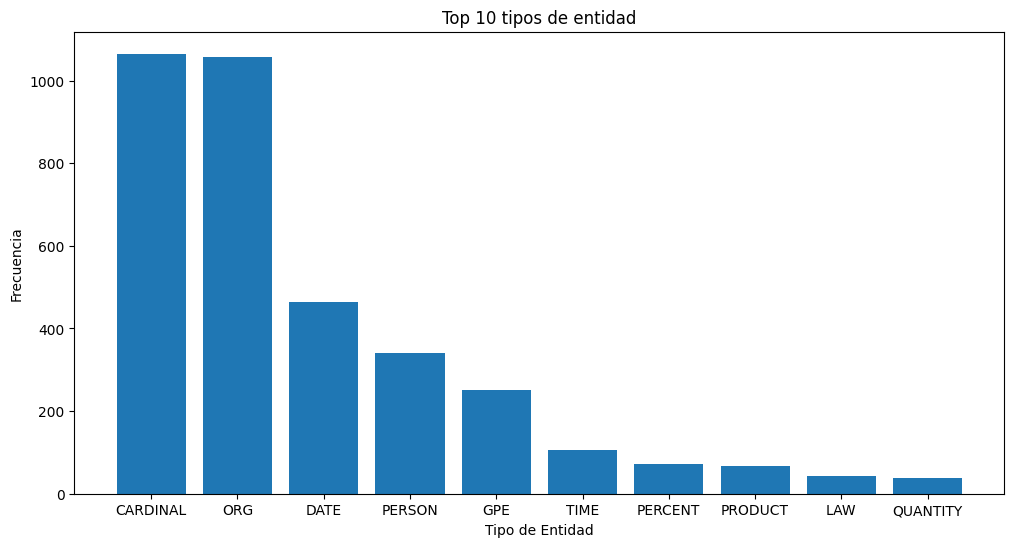

,count
entity,
md,110
two,96
1,92
daily,86
2,82
iop,65
50,59
3,51
q hs ou,48


In [ ]:

# Patrones + visualización

# Top 10 tipos de entidades más frecuentes
top_labels = ents_df["label"].value_counts().head(10)

# Gráfica del top 10 entidades más frecuentes
plt.figure(figsize=(12, 6))
plt.bar(top_labels.index.astype(str), top_labels.values)
plt.title("Top 10 tipos de entidad")
plt.xlabel("Tipo de Entidad")
plt.ylabel("Frecuencia")
plt.show()

# Top 15 entidades textuales más frecuentes
top_ents = ents_df["entity"].str.lower().value_counts().head(15)
top_ents

## Descripción del modelo implementado

El modelo usado en este proyecto es un modelo de reconocimiento de entidades nombradas preentrenado proporcionado por spaCy. Es un modelo de dominio general, es decir no especifico y que no requiere entrenamiento adicional, permitiendo reconocer entidades en un texto. Aunque no está entrenado para el dominio clínico, resulta adecuado para estructurar el texto.

## Resultados

resultados muestran que el modelo NER es capaz de extraer un conjunto significativo de entidades a partir de los textos clínicos analizados. En el gráfico correspondiente a los diez tipos de entidad más frecuentes se observa una clara predominancia de las categorías CARDINAL y ORG, seguidas a cierta distancia por entidades de tipo DATE, PERSON y GPE. Esta descompensación indica que el modelo tiende a identificar con mayor frecuencia valores numéricos y organizaciones en los textos.
Analizando los resultados teniendo en cuenta el contexto clínico de los datos, se observa que muchas de las entidades corresponden a valores numéricos aislados. Esto podría ser debido a que es habitual en los textos clínicos el uso de abreviaturas y la omisión de unidades de medida. Por esto el modelo tiende a clasificar estos valores como entidades de tipo CARDINAL, ya que no dispone del contexto suficiente para poder asignarlos a categorías específicas como QUANTITY.
La baja frecuencia de entidades de tipo PRODUCT puede explicarse por la forma en la que aparecen los medicamentos en las notas clínicas. En muchos casos los fármacos aparecen en los textos clínicos de forma abreviada, con indicaciones incompletas o con pautas de administración, dificultando su identificación como ‘productos’ por parte de un modelo NER genérico. Si nos fijamos en la tabla correspondiente a las quince entidades más repetidas vemos por ejemplo timolol qam ou, donde timolol es un medicamento beta-bloqueante usado en oftalmología, qam es una pauta de administración que indica que se debe tomar el medicamento por la mañana y ou hace referencia a que se debe administrar en ambos ojos, sin embargo, el modelo lo toma como una sola entidad pese a la diferencia entre las partes. Aunque sería deseable que los medicamentos se asociaran a esta categoría, la ausencia de una normalización clínica específica del texto, junto con el uso de un modelo no especializado, limita su correcta detección.
Estos resultados permiten analizar cómo se comportaría el modelo en un entorno hospitalario real, mostrando su capacidad para identificar patrones generales y extraer información relevante de textos clínicos como sus limitaciones al utilizar un modelo de dominio general. Para aplicaciones reales en entornos hospitalarios, sería recomendable emplear modelos específicos del ámbito clínico que permitan una clasificación más precisa de las entidades.

## Conclusión

Este segundo proyecto muestra que es posible estructurar textos clínicos no estructurados mediante técnicas de Procesamiento del Lenguaje Natural. A pesar de las limitaciones derivadas del uso de un modelo genérico de reconocimiento de entidades, los resultados obtenidos son adecuados para un análisis exploratorio inicial y permiten identificar patrones relevantes en los textos, aunque para aplicaciones reales en entornos hospitalarios, sería recomendable emplear modelos específicos del ámbito clínico que permitan una clasificación más precisa de las entidades.

# **Comparación de modelos**

En esta actividad se han evaluado tres modelos diferentes correspondientes a dos tareas distintas. En el primer proyecto se comparan un modelo clásico de análisis de sentimientos basado en TF-IDF para la extracción de características y Naive Bayes que actúa como clasificador probabilístico, con un modelo avanzado y preentrenado basado en Transformers, como BERT. En cambio, en el segundo proyecto se emplea un modelo de reconocimiento de entidades nombradas para la estructuración de textos clínicos.

Los resultados muestran que el modelo clásico ofrece un rendimiento competitivo en el análisis de sentimientos, cabe destacar su sencillez y su bajo coste computacional. El modelo basado en BERT también ofrece un buen rendimiento en el análisis de sentimientos aportando ventajas en la modelización del contexto y en las métricas basadas en probabilidades, aunque a costa de una mayor complejidad. Por último, el modelo NER demuestra su potencial en tareas de PLN para estructurar la información clínica, aunque su rendimiento se ve limitado por el uso de un modelo genérico y la utilización de acrónimos en el lenguaje clínico.